In [1]:
import xscen as xs
import xarray as xr
from xscen import CONFIG
from matplotlib import pyplot as plt
import xclim as xc
import figanos.matplotlib as fg
from datetime import datetime
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
import numpy as np
import random
import glob
fg.utils.set_mpl_style('ouranos')
xs.load_config("../config/config_general.yml", "../config/config_region.yml", "../config/paths.yml")

/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/esmf/8.8.0/lib/python3.11/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# health checks

In [2]:
# print any health checks raised
for f in np.sort(glob.glob(f"{CONFIG['paths']['final']}/checks/NAM-C3/*")):
    print(f.split("/")[-1])
    ds= xr.open_zarr(f)
    for var in ds.data_vars:
        if ds[var].values:
            print(var, ds[var].values)

CMIP6_ScenarioMIP_CCCma_CanESM5_ssp126_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CCCma_CanESM5_ssp534-over_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmax_temperature_extremely_high True
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CNRM-CERFACS_CNRM-ESM2-1_ssp534-over_r1i1p1f2_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp585_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
pr_very_large_precipitation_events True
tasmax_temperature_extremely_high True
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CSIRO_ACCESS-ESM1-5_ssp126_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmin_temperature_extremely_low True
CMIP6_ScenarioMIP_CSIRO_ACCESS-ESM1-5_ssp585_r1i1p1f1_global+CaSRv32+NAM-C3_checks.zarr.zip
tasmax_te

# diagnostiques VALUE

/tmp/ipykernel_311901/1187489313.py:10: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'properties' ('properties',) The recommendation is to set join explicitly for this case.


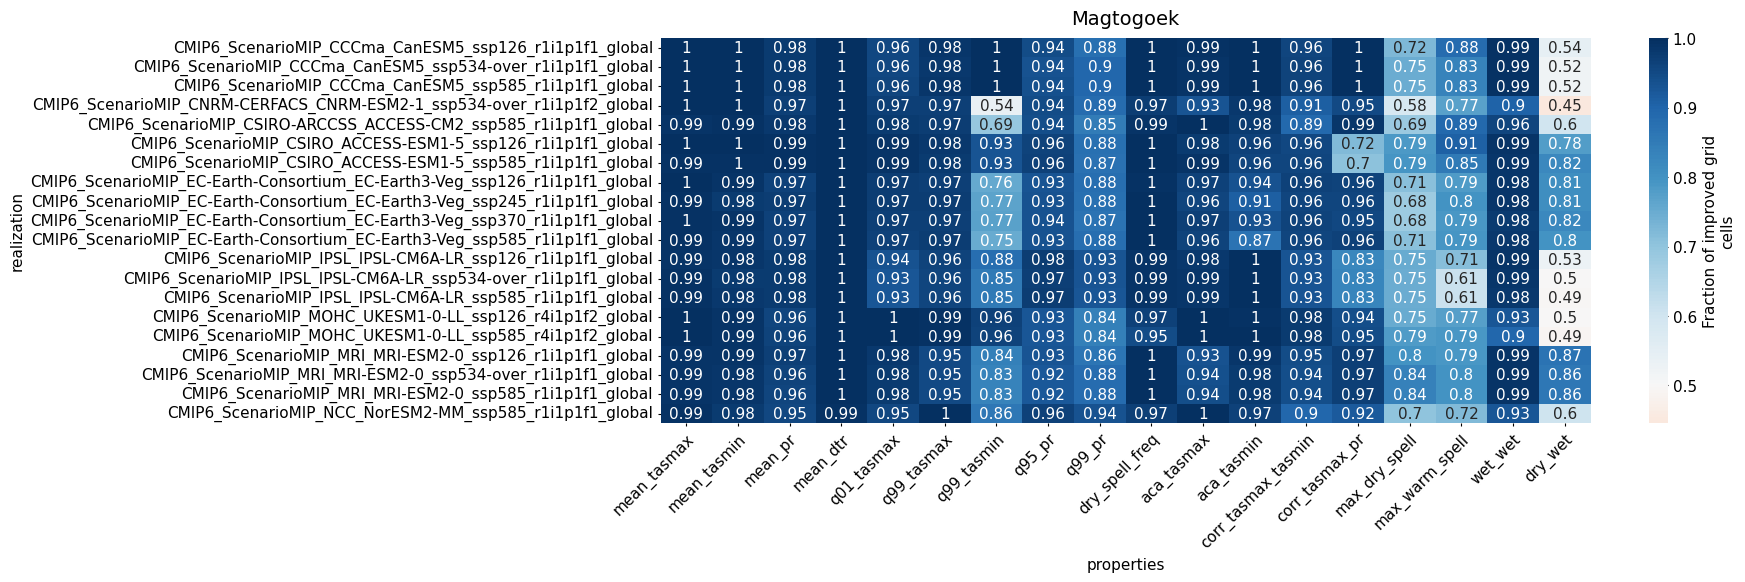

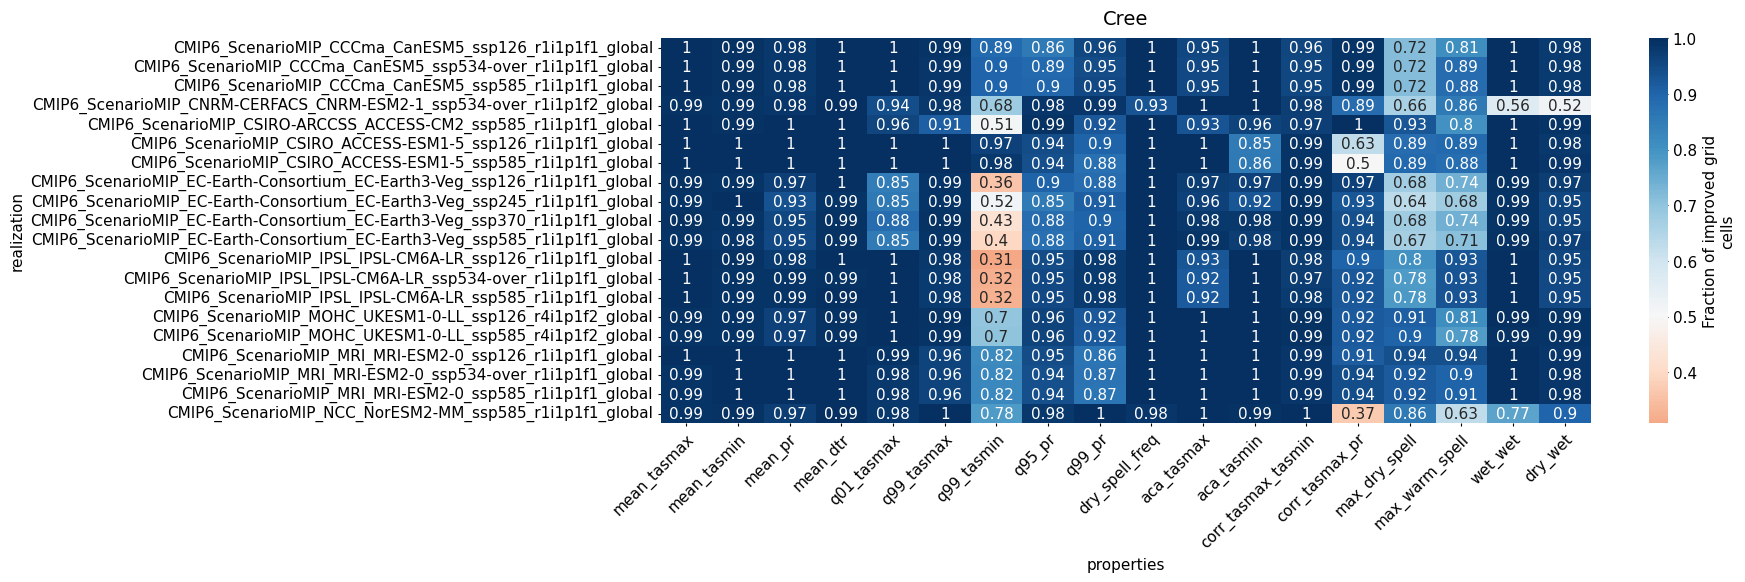

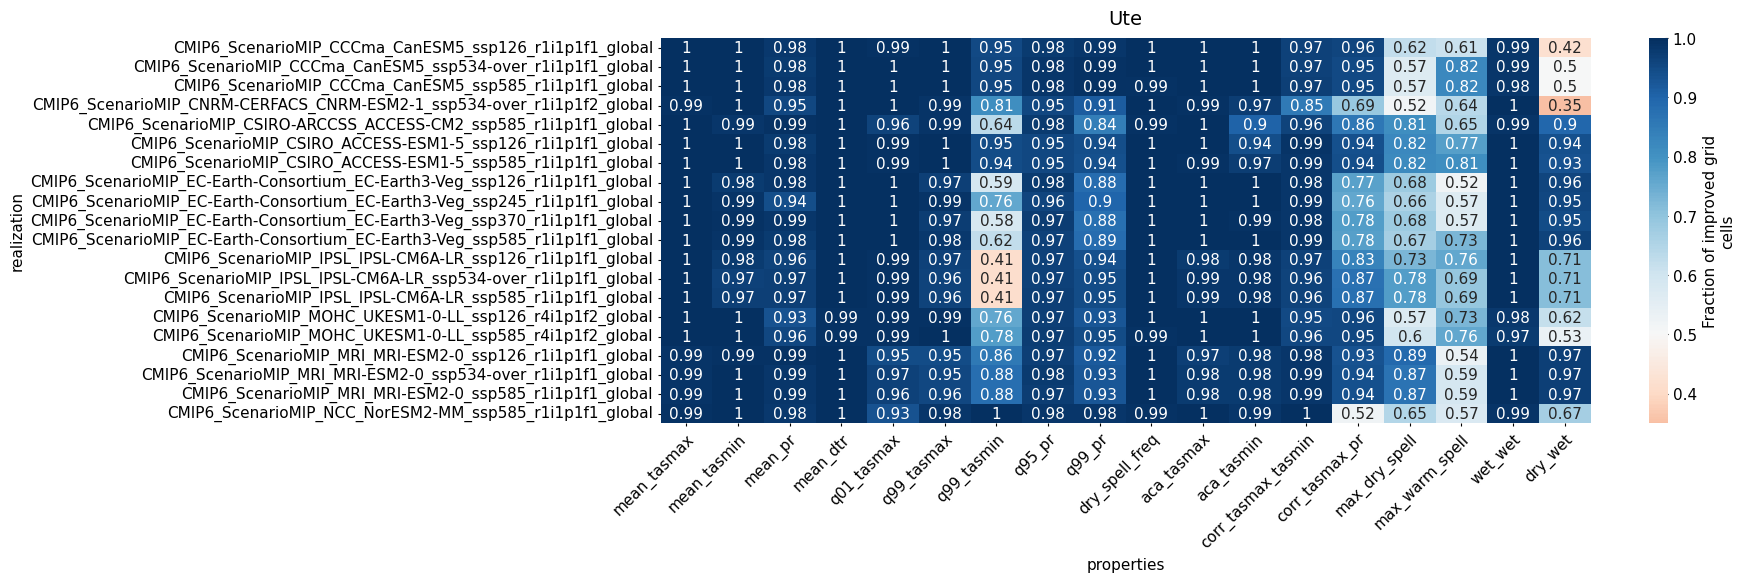

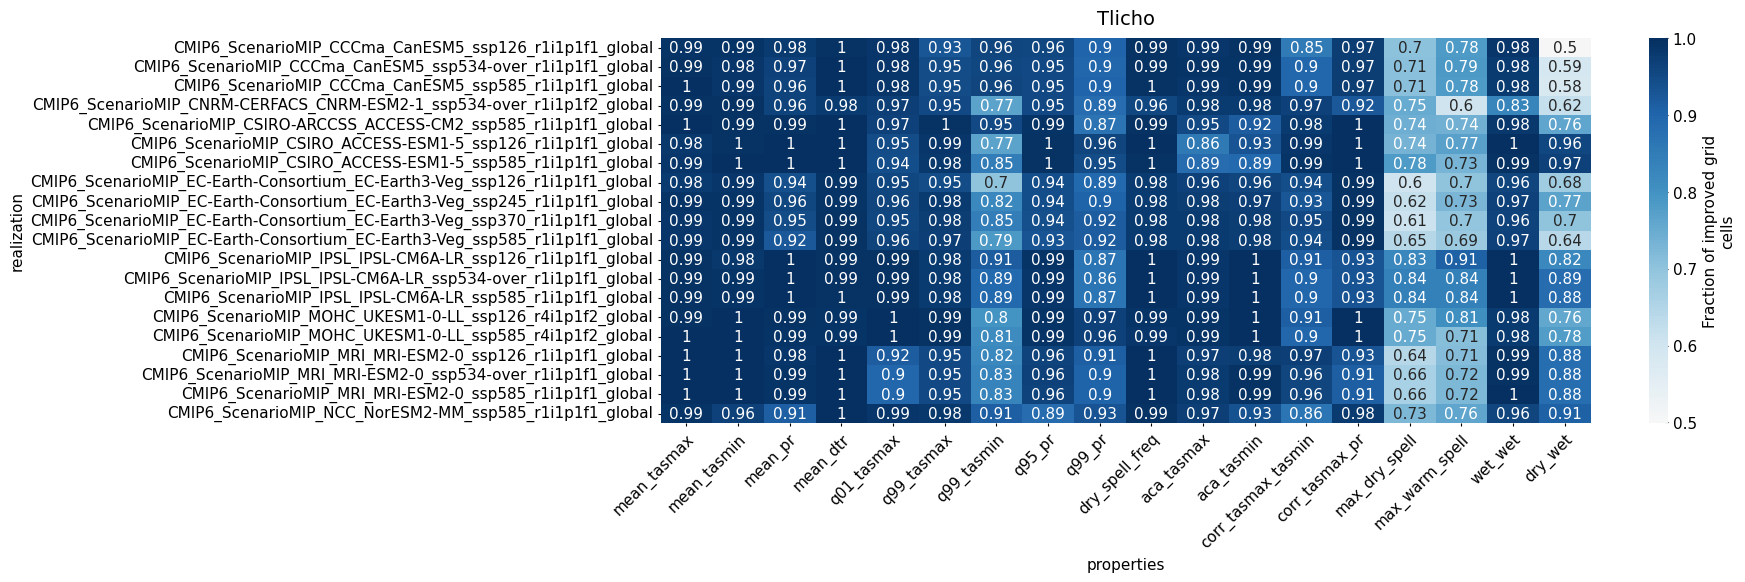

In [3]:


for r in ['Magtogoek','Cree','Ute','Tlicho']:

    imps=[]
    for f in np.sort(glob.glob(f"{CONFIG['paths']['final']}/diagnostics/CaSRv32/NAM-C3/{r}/CMIP6*/*imp.zarr.zip")):
        imp=xr.open_zarr(f, decode_timedelta=False)
        imp=imp.expand_dims(realization=[imp.attrs['cat:id']])
        
        imps.append(imp)

    ds_imp= xr.concat(imps, dim='realization')
    ds_imp=ds_imp.sel(properties=["mean_tasmax","mean_tasmin","mean_pr","mean_dtr","q01_tasmax","q99_tasmax","q99_tasmin","q95_pr","q99_pr","dry_spell_freq","aca_tasmax","aca_tasmin","corr_tasmax_tasmin","corr_tasmax_pr","max_dry_spell","max_warm_spell","wet_wet","dry_wet",])
    ds_imp=ds_imp.drop_vars('rotated_pole')
    
    ax=fg.heatmap(ds_imp,plot_kw={'annot':True, }, fig_kw={'figsize':(15,5)}, divergent=0.5)
    ax.set_title(r)


# plot 1 day

/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/scenario/environnements/envs/xscen-0.13/lib/python3.11/site-packages/figanos/matplotlib/utils.

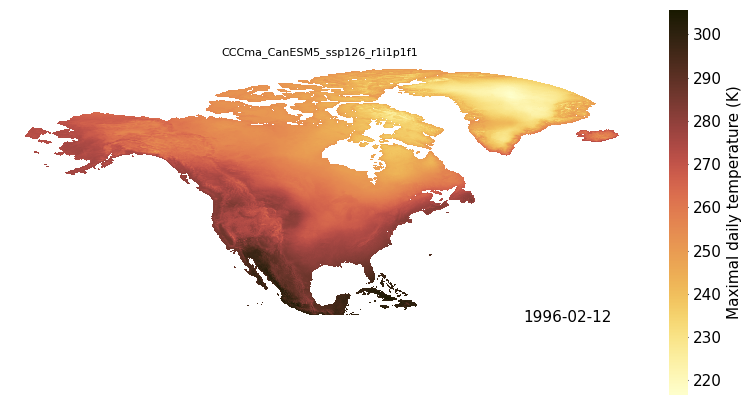

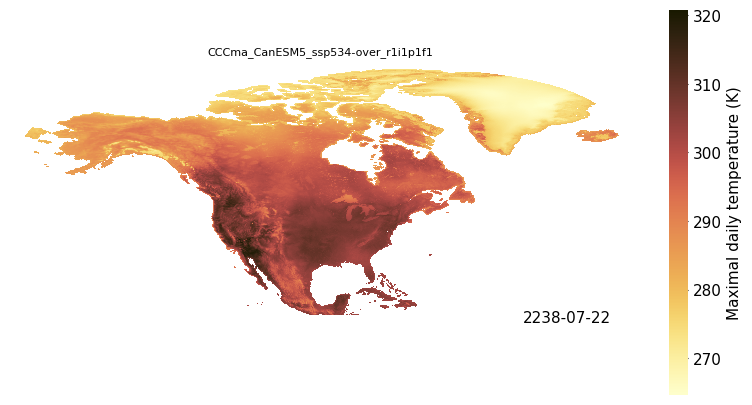

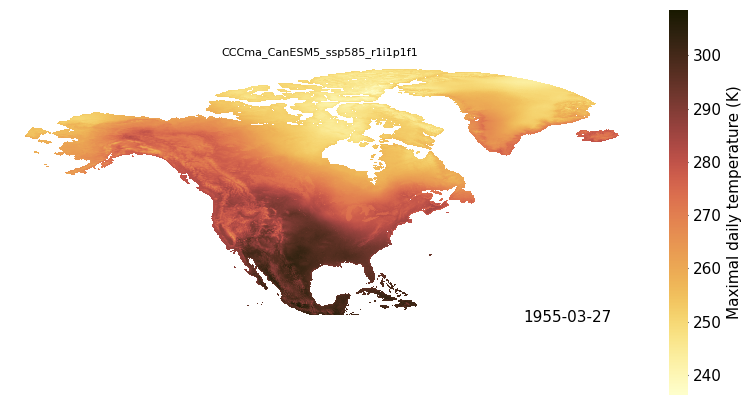

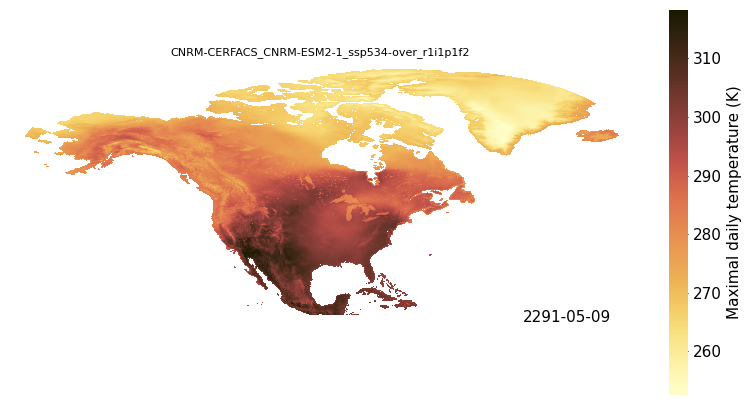

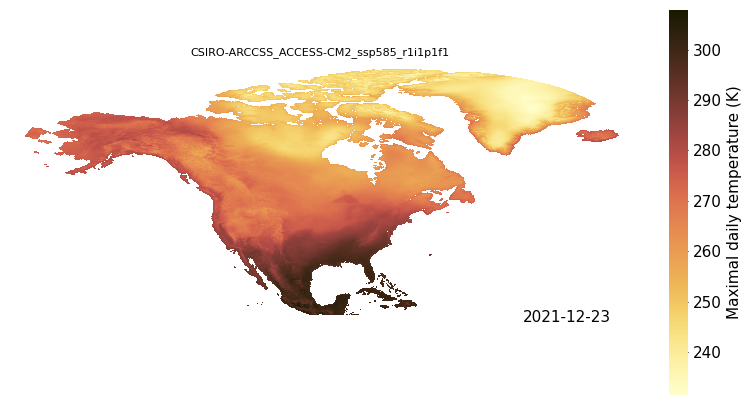

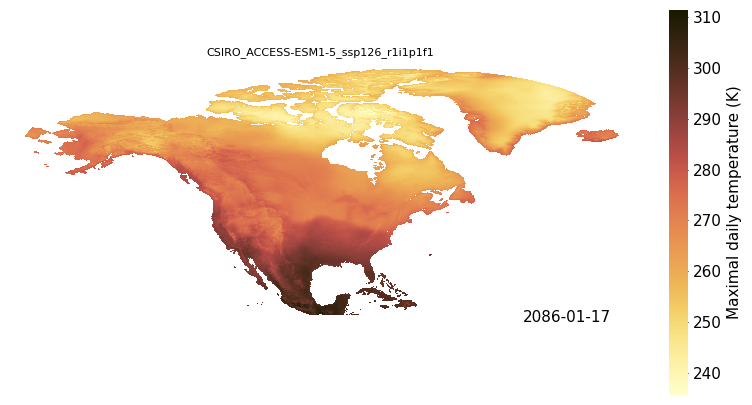

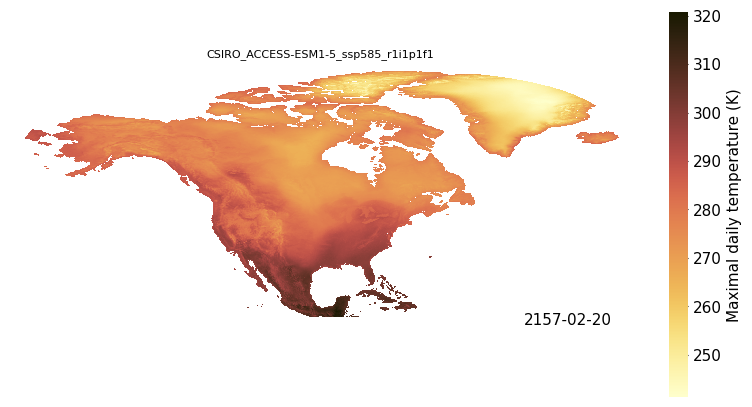

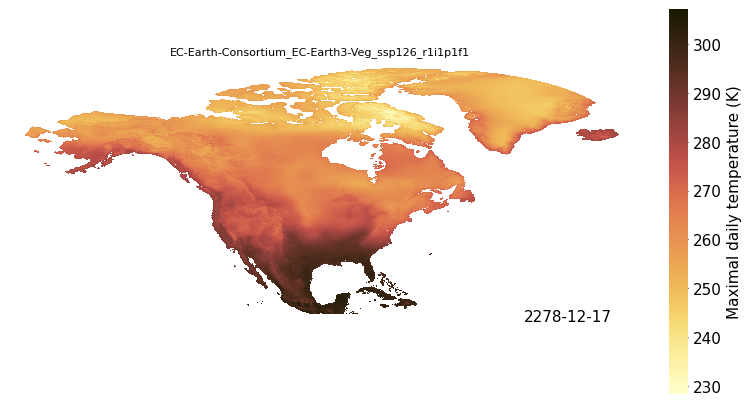

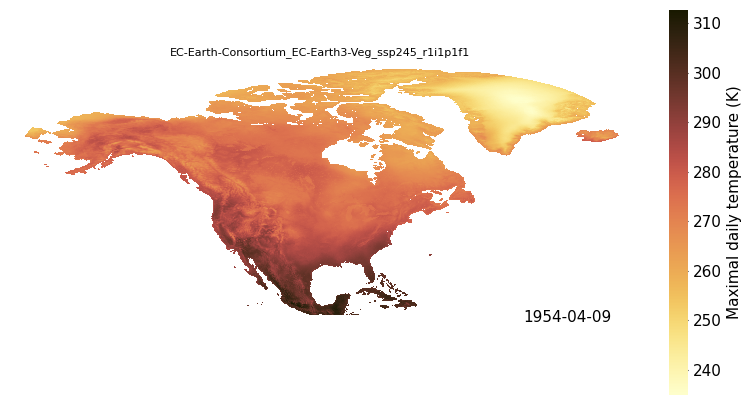

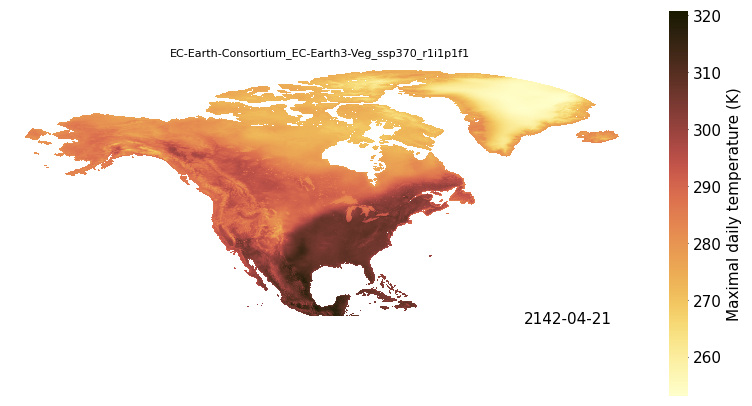

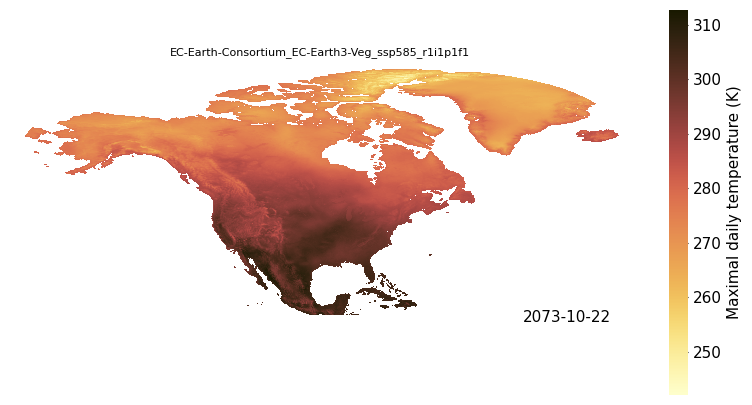

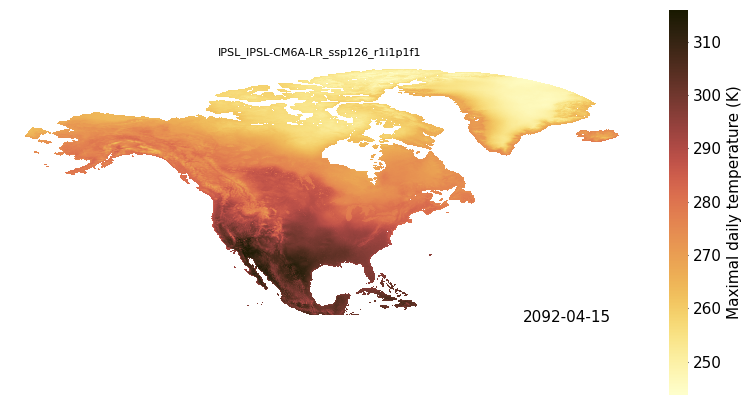

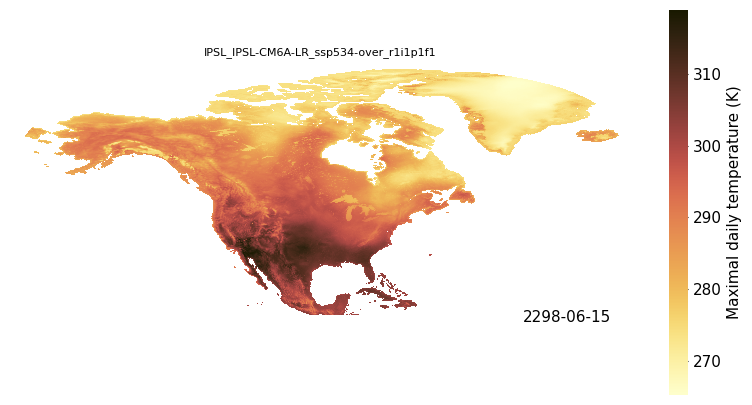

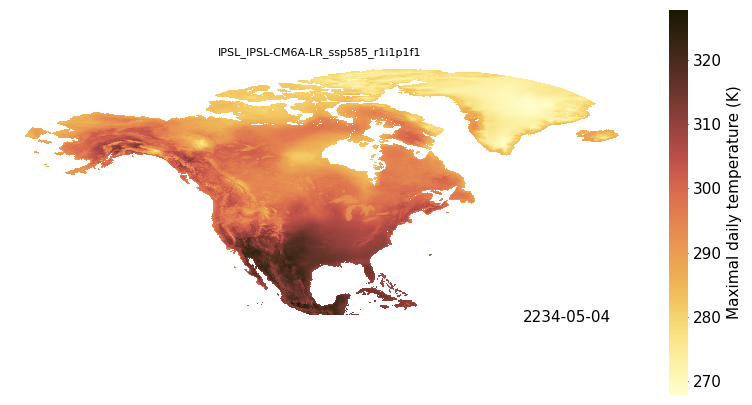

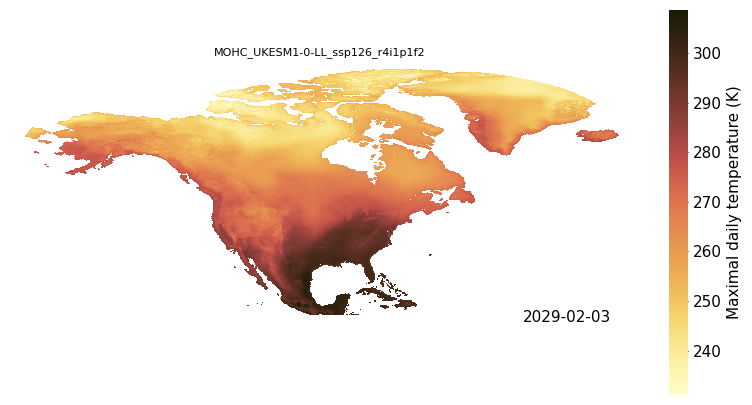

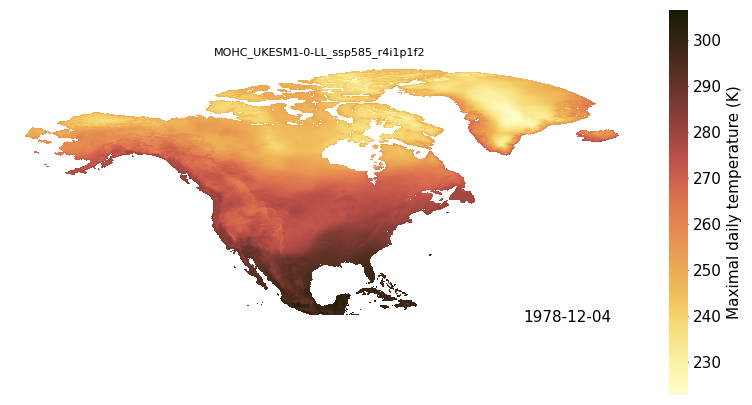

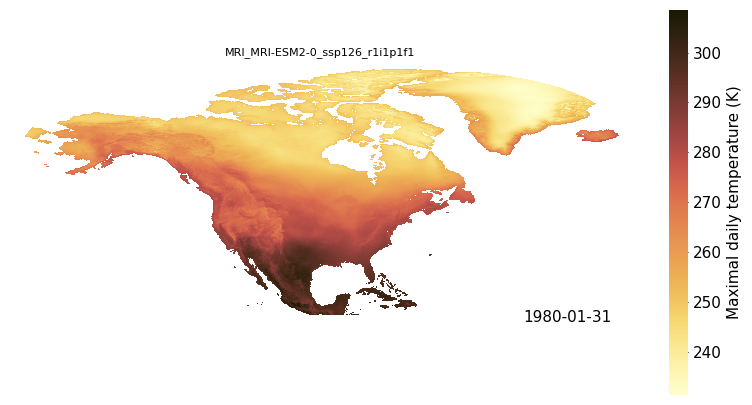

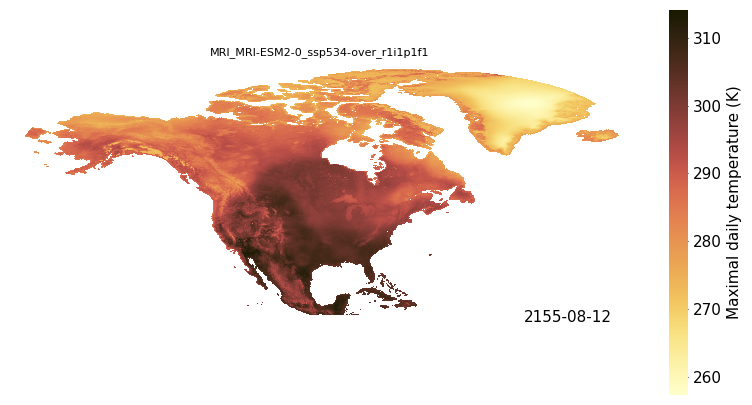

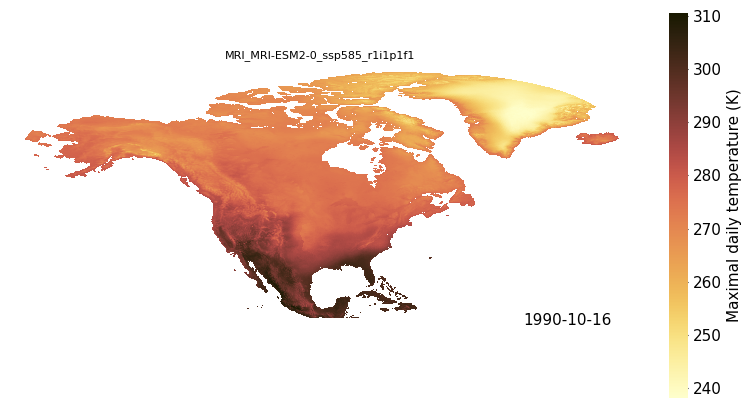

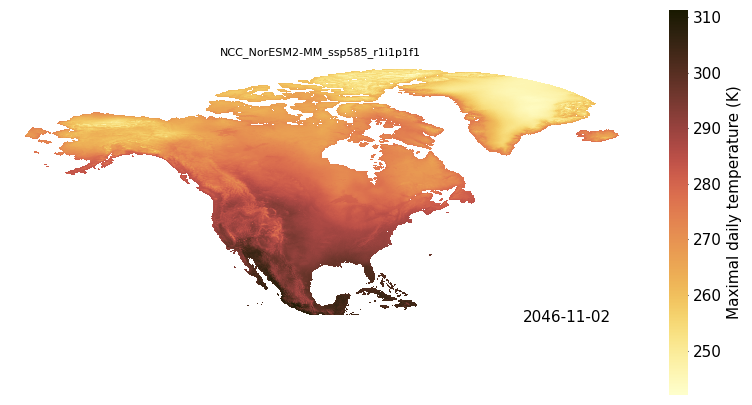

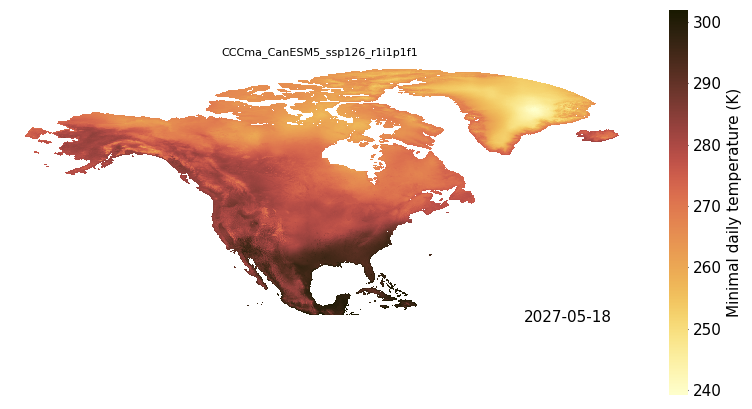

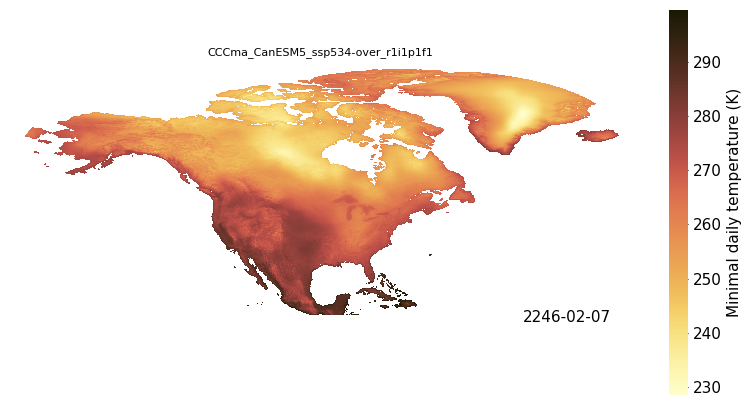

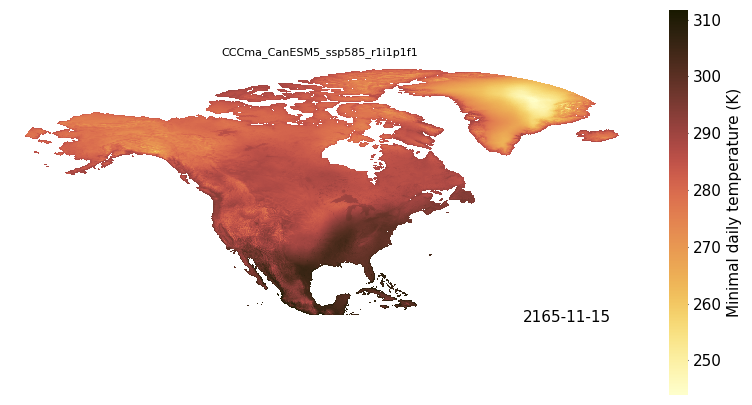

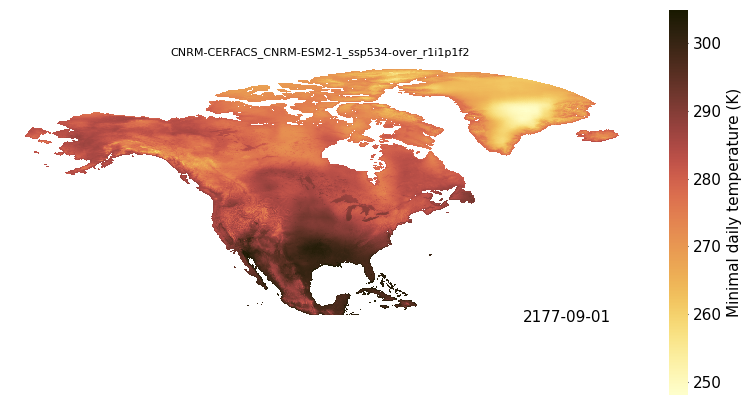

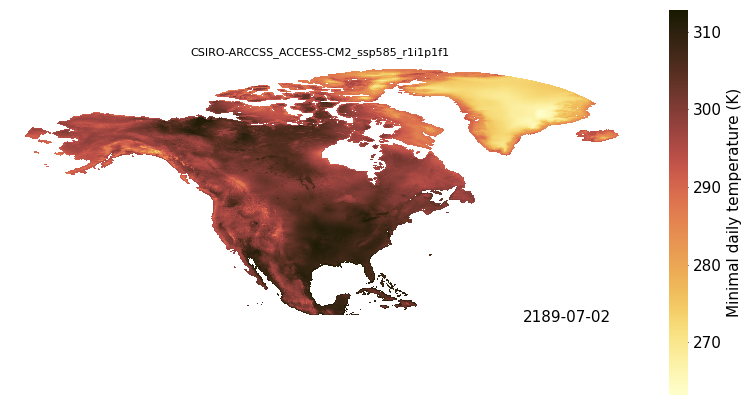

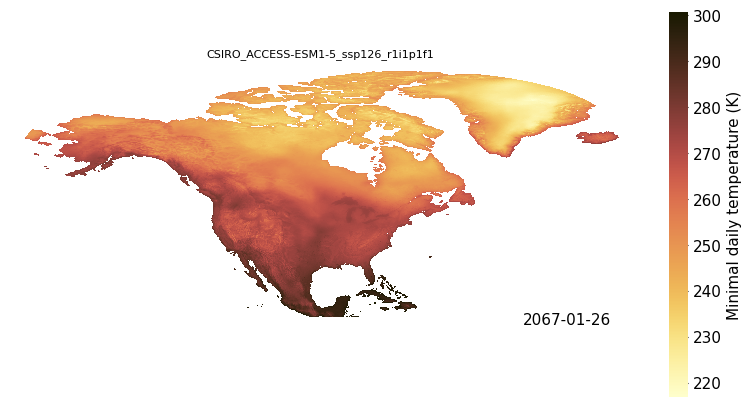

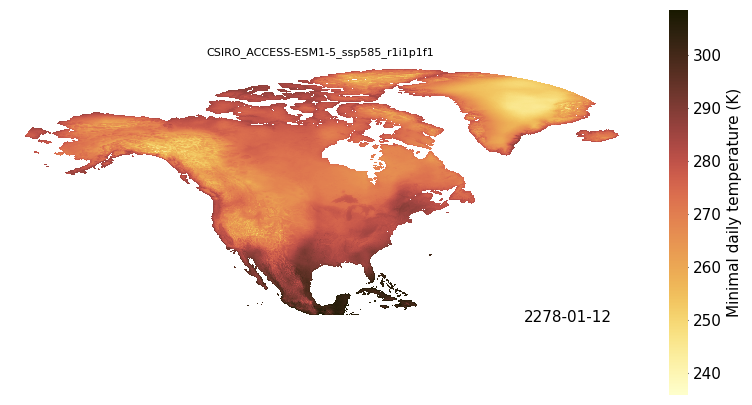

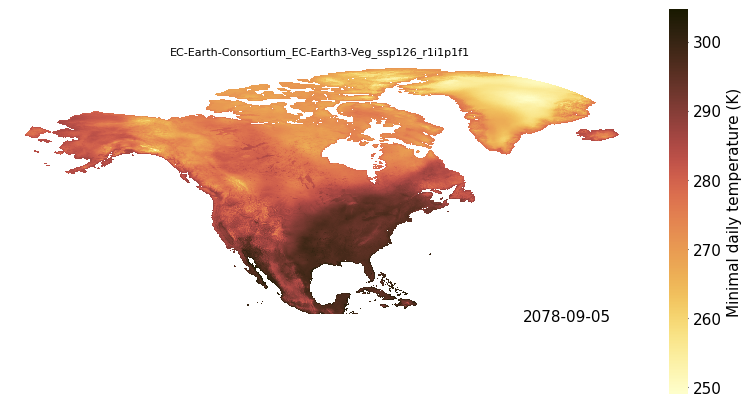

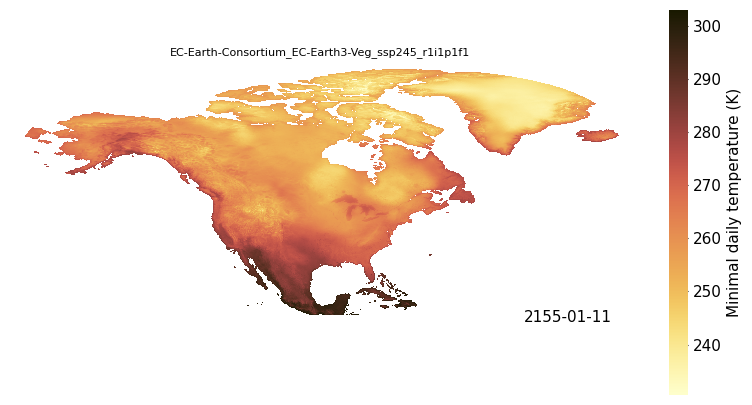

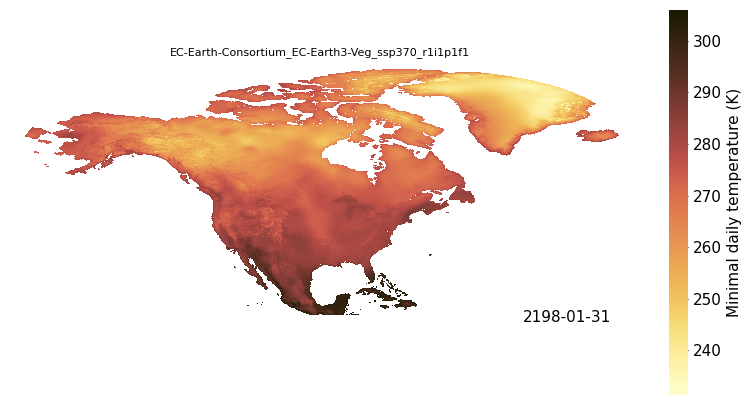

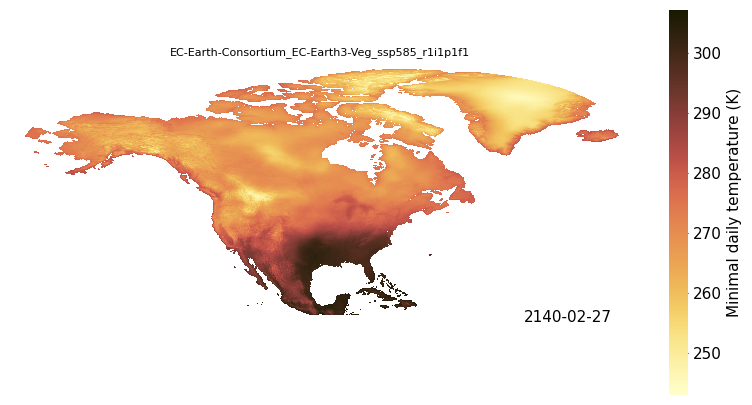

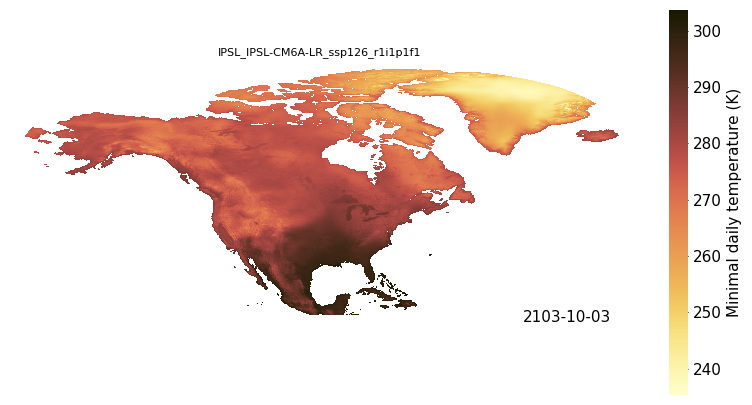

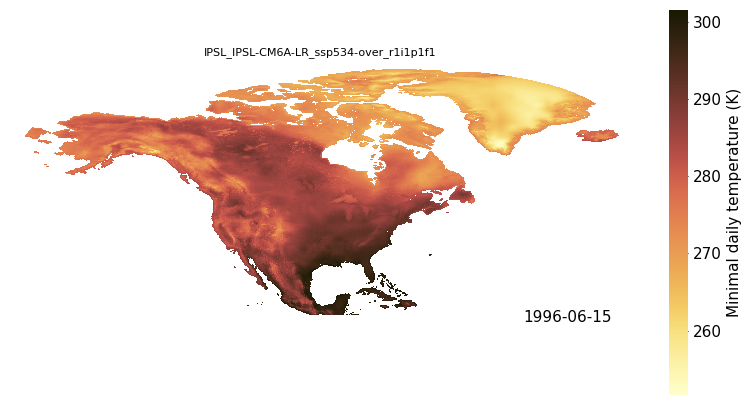

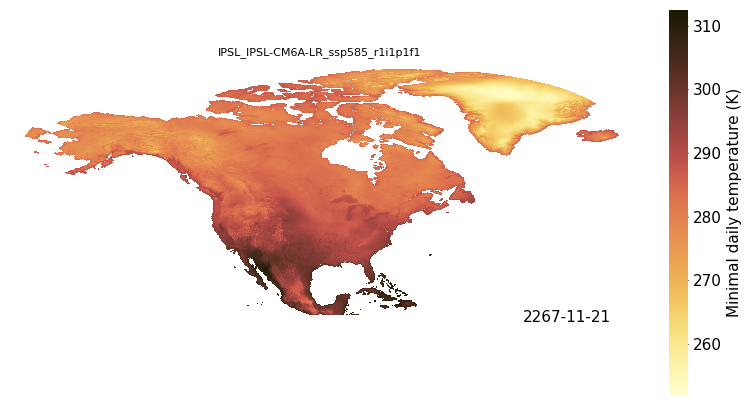

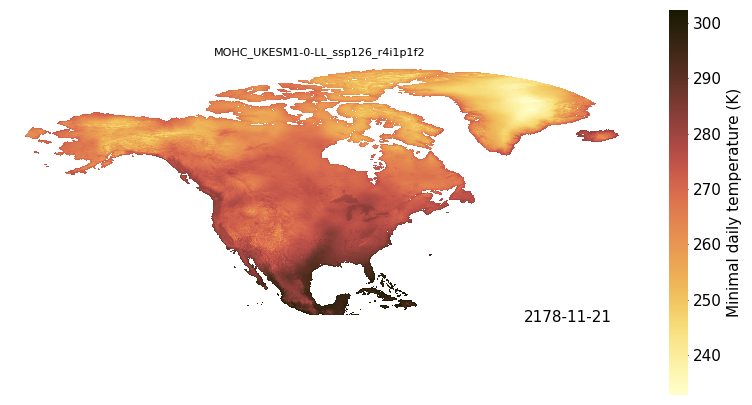

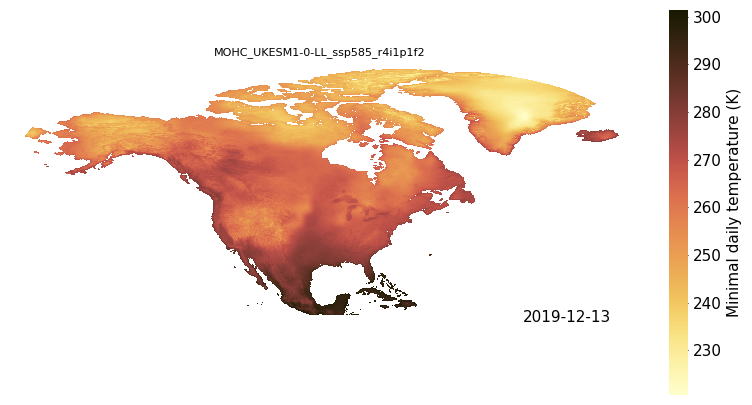

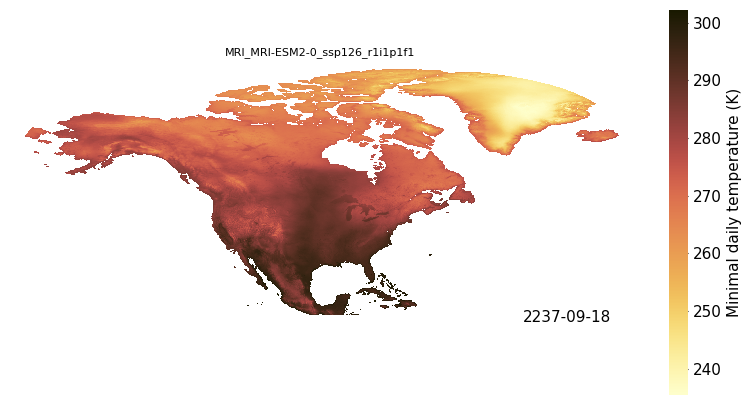

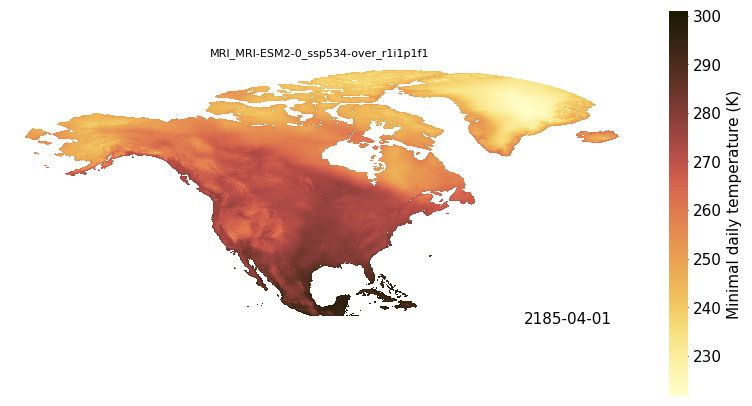

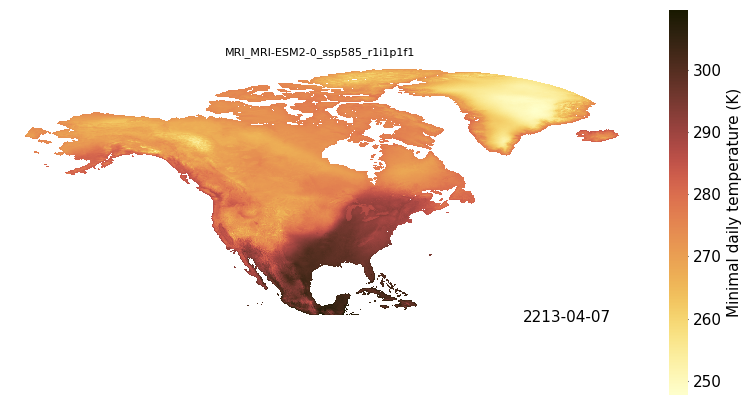

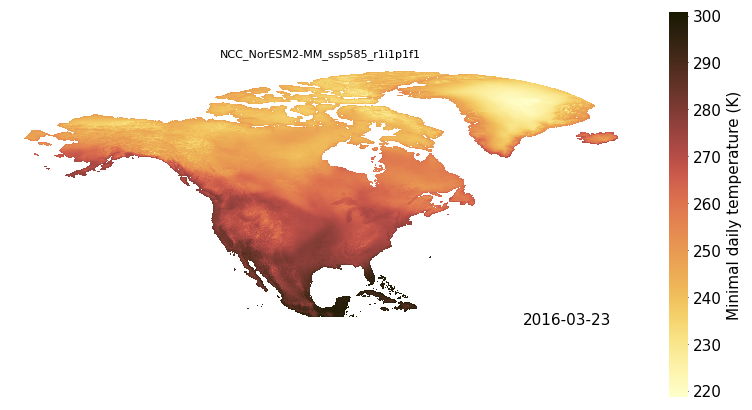

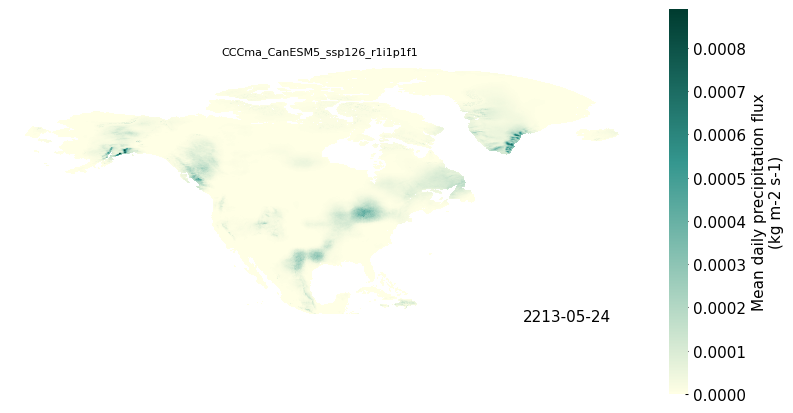

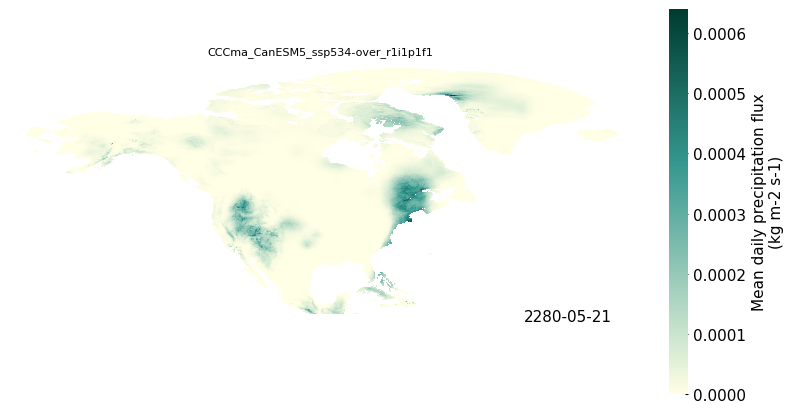

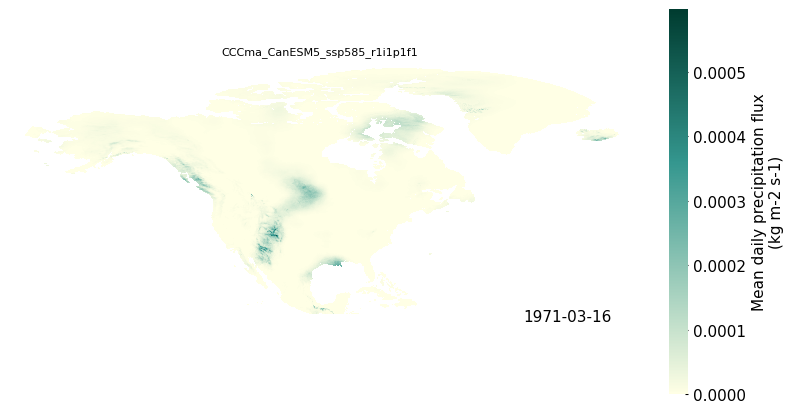

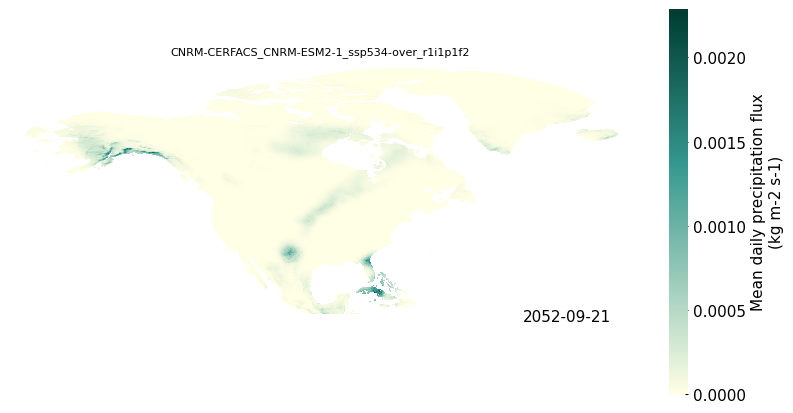

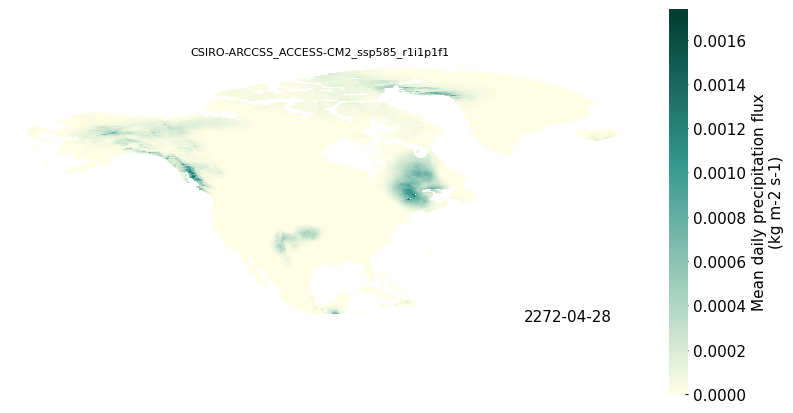

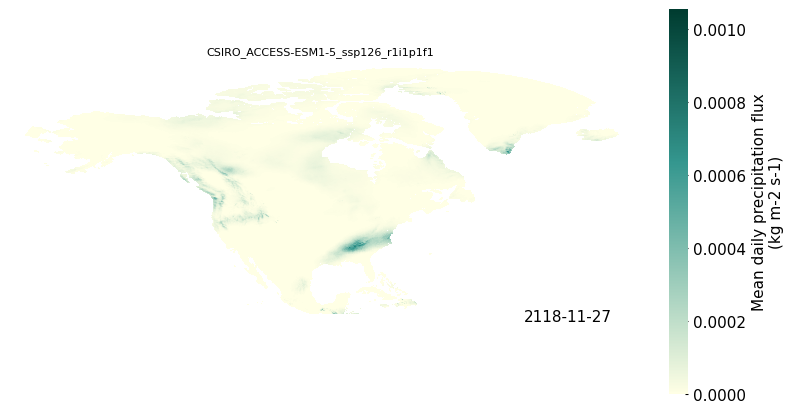

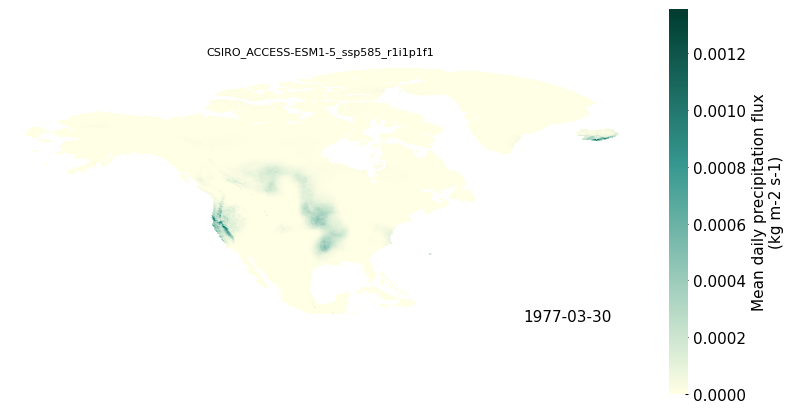

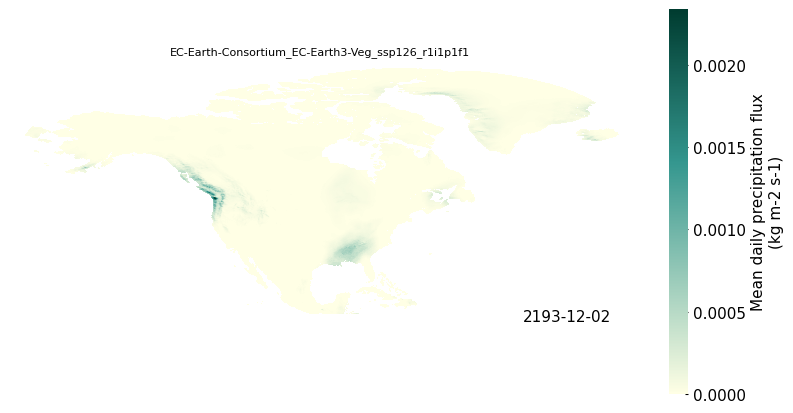

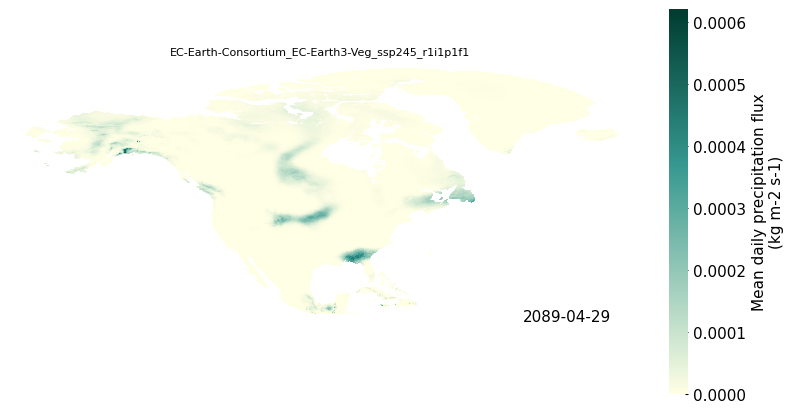

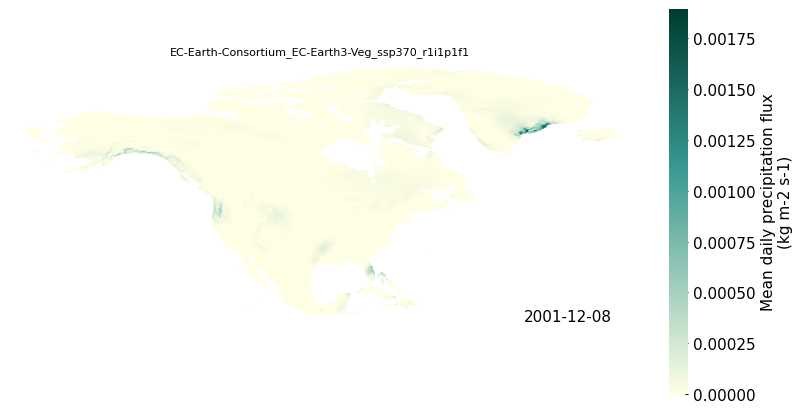

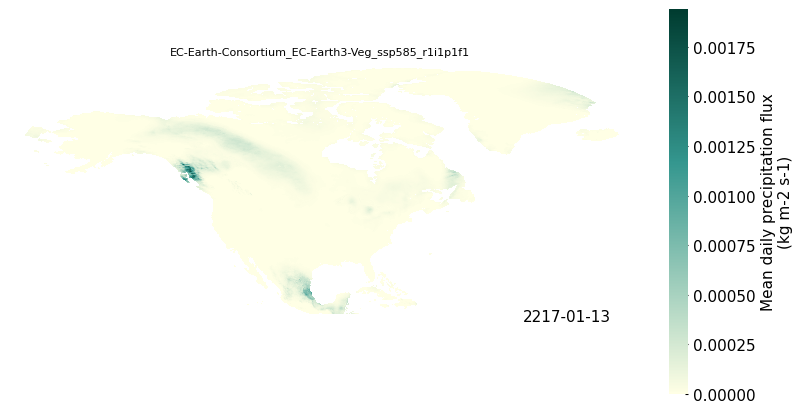

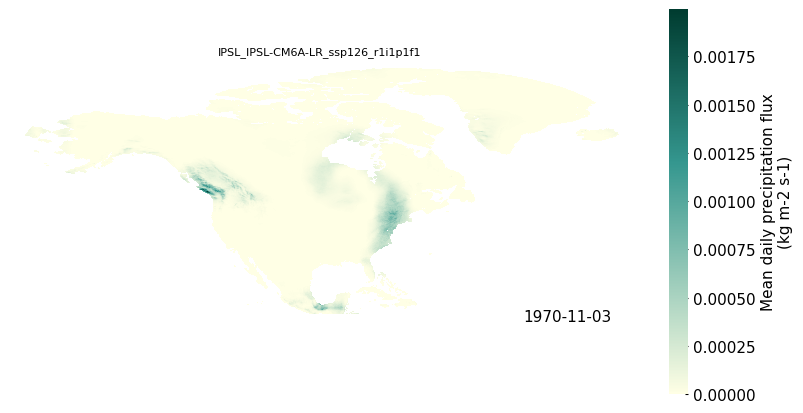

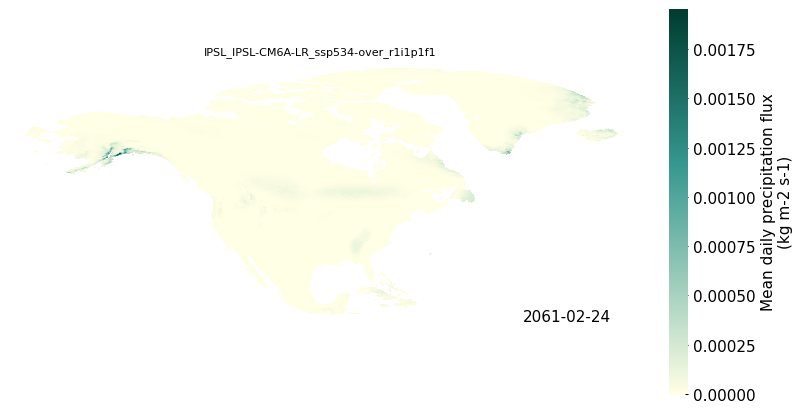

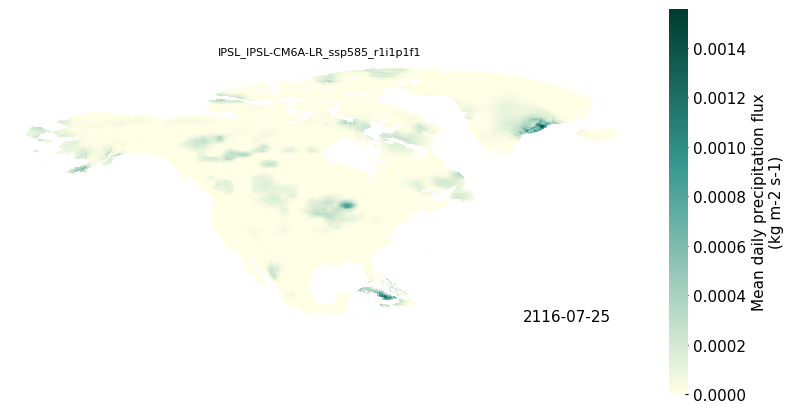

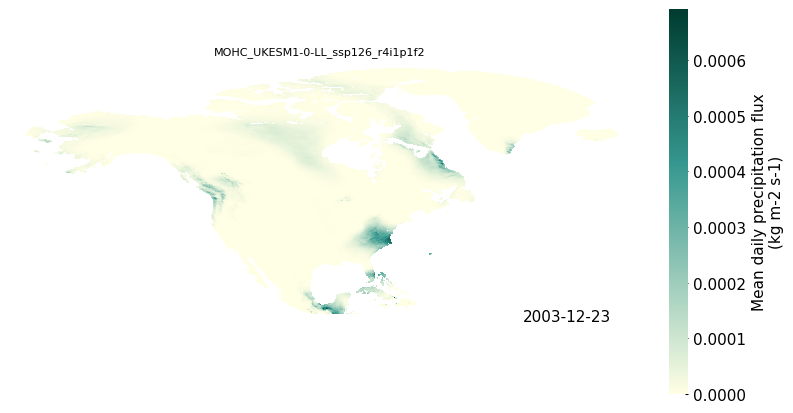

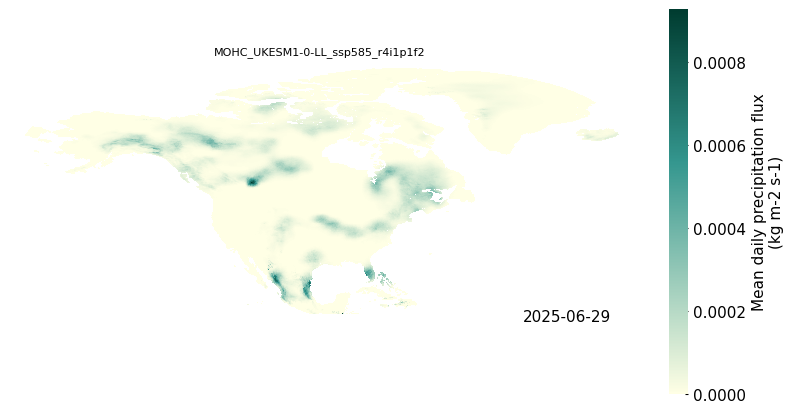

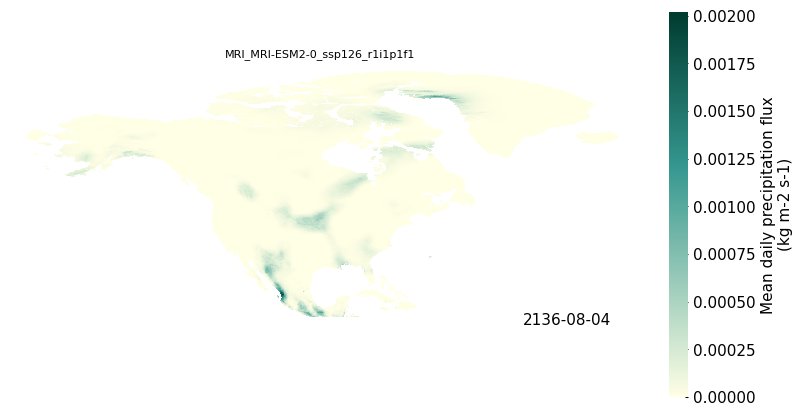

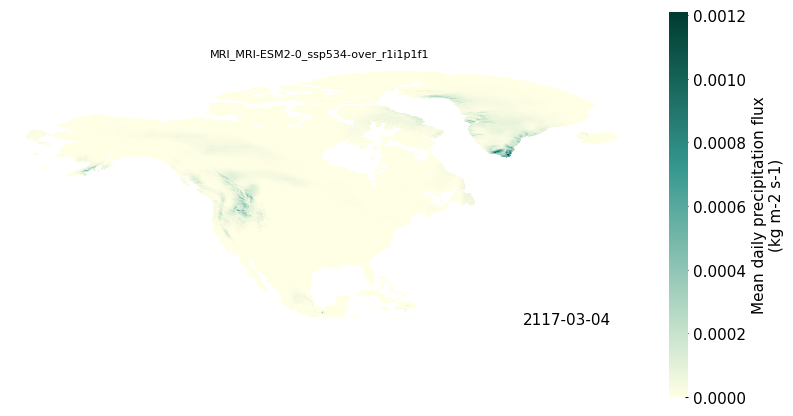

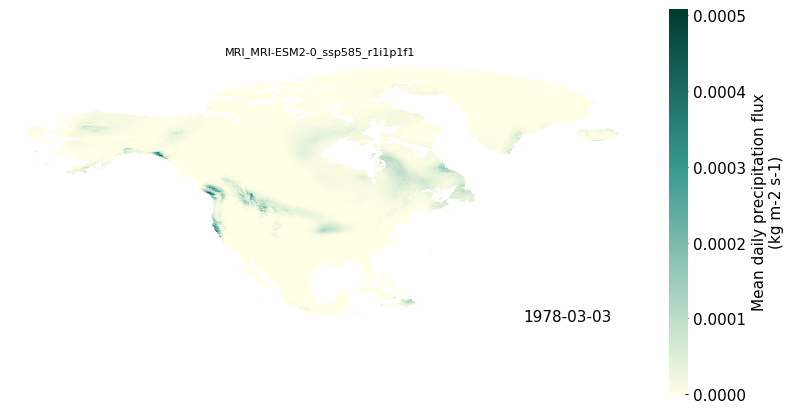

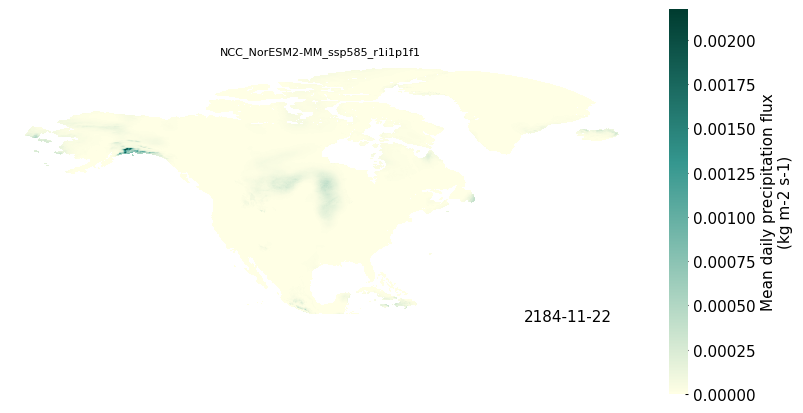

In [4]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
for var in ['tasmax','tasmin', 'pr']:
    for f in np.sort(glob.glob(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO6-post2100_v2.0/CMIP6/ScenarioMIP/NAM-C3/*/*/*/*/*/*/*{var}*")):
        ds=xr.open_zarr(f, decode_times=time_coder)
        ax=fg.gridmap(ds.isel(time=random.randint(0, len(ds.time))),plot_kw={ "cbar_kwargs": {"shrink": 0.5,}},fig_kw={'figsize':(10,10)}, show_time=True  )
        ax.set_extent([-179.95, -10, 10, 83.4 ], crs=ccrs.PlateCarree())
        ax.set_title(ds.attrs['cat:id'].replace('CMIP6_ScenarioMIP_','').replace('_global',''), fontsize=8)
